In [1]:
import sys
import os
import pandas as pd
import numpy as np
import csv
import pip
import seaborn as sns
import matplotlib.pyplot as plt
from functools import reduce
import statsmodels.api as sm
import linearmodels as lm
from linearmodels import PanelOLS, RandomEffects
from scipy import stats
from linearmodels import RandomEffects
import statsmodels.api as sm
from linearmodels.panel import compare

In [2]:
final_df = pd.read_csv("prepared_data_for_regression.csv")
print(final_df.head(5))

       country  year  incidence  mortality           gdp       bmi    pop_65  \
0         chad  1990  11.784239  15.747424   1705.042265  0.038681  3.455495   
1        india  1990   8.650421   8.913174   2203.147039  0.014403  4.037870   
2  puerto rico  1990  51.408888  18.715862           NaN  0.044402       NaN   
3         oman  1990   5.197615   6.765138  35201.552487  0.052449  2.453040   
4       zambia  1990  14.798816  20.414687   2425.111287  0.110025  2.880287   

   urban_pop  life_exp  fertility  labor_rate  
0     20.811    48.799      7.219      64.570  
1     25.547    59.358      4.045      30.225  
2        NaN       NaN        NaN         NaN  
3     66.102    71.752      6.456      22.489  
4     39.407    49.410      6.567      51.414  


In [3]:
initial_countries=final_df['country'].nunique()
print(initial_countries)

202


In [4]:
initial_years=final_df['year'].nunique()
print(initial_years)

34


In [5]:
total_observation=len(final_df)
print(total_observation)

6868


# OECD  Countries :

In [6]:
oecd_countries = ['austria', 'australia', 'belgium', 'canada', 'chile', 
                  'columbia', 'czech republic', 'denmark', 'estonia', 'finland', 
                  'france', 'germany', 'greece', 'hungary', 'iceland', 'ireland', 
                  'israel', 'italy', 'japan', 'korea', 'latvia', 'lithuania', 'luxembourg', 
                  'mexico', 'netherlands', 'new zealand', 'norway', 'poland', 'portugal', 'slovak republic', 
                  'slovenia', 'spain', 'sweden', 'switzerland', 'turkey', 'united kingdom', 'united states']

# Creat Dummy Variables:

In [7]:
#final_df['is_oecd'] = final_df['country'].isin(oecd_list).astype(int)
final_df['is_oecd'] = final_df['country'].isin(oecd_countries).astype(int)

# creat interaction :

is_oecd
0    5814
1    1054
Name: count, dtype: int64


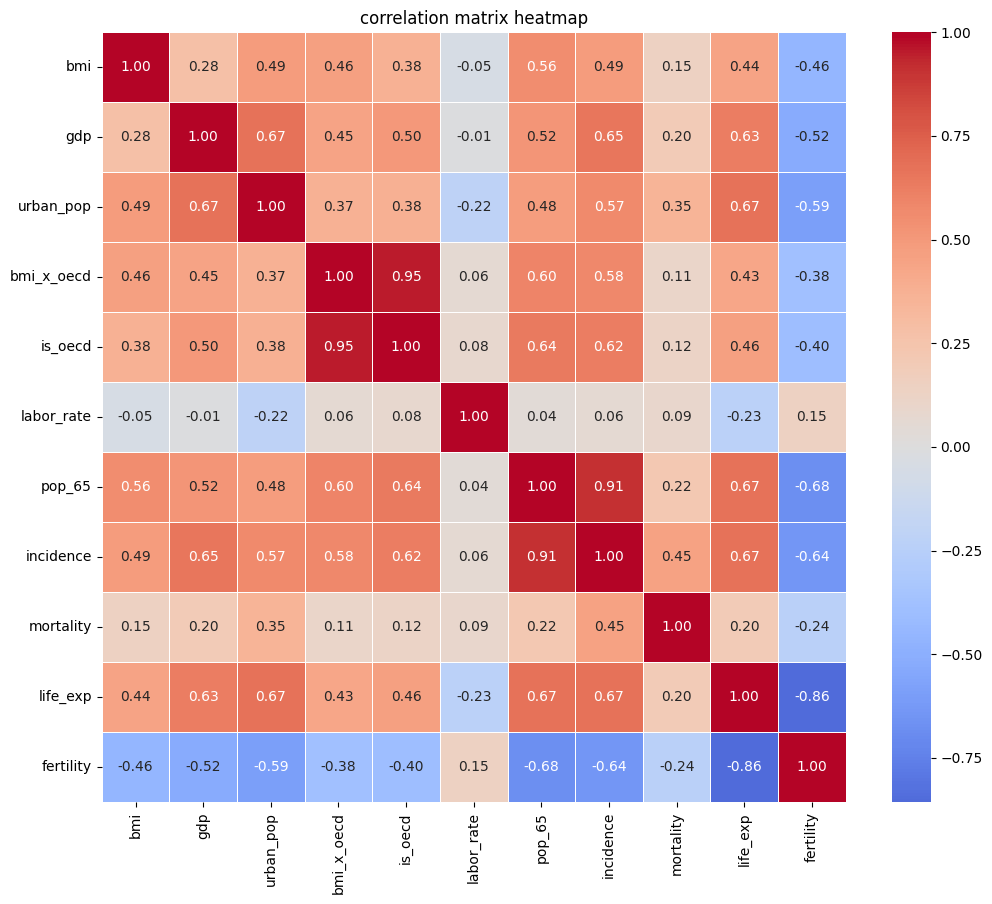

In [8]:
final_df['bmi_x_oecd'] = final_df['bmi']* final_df['is_oecd']
print(final_df['is_oecd'].value_counts())
columns_for_heatmap=['bmi', 'gdp', 'urban_pop', 'bmi_x_oecd', 'is_oecd', 'labor_rate', 'pop_65'
                      ,'incidence', 'mortality', 'life_exp', 'fertility']
correlation_matrix = final_df[columns_for_heatmap].corr()
plt.figure(figsize= (12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0, linewidths=0.5)
plt.title('correlation matrix heatmap')
plt.show()

# Dummy Variables: 

In [9]:
final_df['is_oecd']= final_df['country'].str.lower().str.strip().isin(oecd_countries).astype(int)
print(final_df['is_oecd'].value_counts())

is_oecd
0    5814
1    1054
Name: count, dtype: int64


In [10]:
oecd_comparison= final_df.groupby('is_oecd').incidence.mean()
print(final_df['is_oecd'].value_counts())

is_oecd
0    5814
1    1054
Name: count, dtype: int64


1. Aging Society Dummy: Based on WHO standards, societies with >10% population over 65 are considered "ageing" or "aged". This captures potential non-linear increases in cancer incidence due to population structure.

In [11]:
final_df['dm_high_aging_society'] = (final_df['pop_65'] > 10).astype(int)
print(final_df['dm_high_aging_society'].value_counts())

dm_high_aging_society
0    5096
1    1772
Name: count, dtype: int64


2. High Life Expectancy Dummy threshold of 75 years represents advanced healthcare systems and higher probability of disease detection.

In [12]:
final_df['dm_high_life_exp']=(final_df['life_exp']> 75).astype(int)
print(final_df['dm_high_life_exp'].value_counts())

dm_high_life_exp
0    4169
1    2699
Name: count, dtype: int64


In [13]:
comparison_inc= final_df.groupby('dm_high_life_exp').incidence.mean()
print(comparison_inc)

dm_high_life_exp
0    28.212153
1    89.538242
Name: incidence, dtype: float64


In [14]:
comparison_mortal= final_df.groupby('dm_high_life_exp').mortality.mean()
print(comparison_mortal)

dm_high_life_exp
0    18.465844
1    20.934162
Name: mortality, dtype: float64


In [15]:
print(final_df[['year', 'country', 'is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].head(100))

    year          country  is_oecd  dm_high_aging_society  dm_high_life_exp
0   1990             chad        0                      0                 0
1   1990            india        0                      0                 0
2   1990      puerto rico        0                      0                 0
3   1990             oman        0                      0                 0
4   1990           zambia        0                      0                 0
..   ...              ...      ...                    ...               ...
95  1990          finland        1                      1                 1
96  1990     cook islands        0                      0                 0
97  1990          jamaica        0                      0                 0
98  1990  north macedonia        0                      0                 0
99  1990      south sudan        0                      0                 0

[100 rows x 5 columns]


# interaction of is_oecd variable and gdp

In [16]:
final_df['gdp_is_oecd']= final_df['gdp']*final_df['is_oecd']
print(final_df['gdp_is_oecd'].head(5))

0    0.0
1    0.0
2    NaN
3    0.0
4    0.0
Name: gdp_is_oecd, dtype: float64


In [17]:
print(final_df[['year', 'country', 'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))

      year                           country  gdp_is_oecd  \
6768  2022                         indonesia          0.0   
6769  2022  lao people's democratic republic          NaN   
6770  2022  micronesia (federated states of)          NaN   
6771  2022                  papua new guinea          0.0   
6772  2022                          eswatini          0.0   
...    ...                               ...          ...   
6863  2023                          dominica          0.0   
6864  2023                         argentina          0.0   
6865  2023                dominican republic          0.0   
6866  2023                             nauru          0.0   
6867  2023                              niue          NaN   

      dm_high_aging_society  dm_high_life_exp  
6768                      0                 0  
6769                      0                 0  
6770                      0                 0  
6771                      0                 0  
6772                      0

In [18]:
start_year=final_df['year'].min()
end_year=final_df['year'].max()
print(final_df[['year', 'country', 'dm_high_aging_society', 'dm_high_life_exp']].tail(100))
start_count= final_df[final_df['year']== start_year]['dm_high_life_exp'].sum() 
end_count=final_df[final_df['year']== end_year]['dm_high_life_exp'].sum()
print(f"number of countries with high life_expectency in {start_count}")
print(f"number of countries with high life_expectency in {end_count}")

      year                           country  dm_high_aging_society  \
6768  2022                         indonesia                      0   
6769  2022  lao people's democratic republic                      0   
6770  2022  micronesia (federated states of)                      0   
6771  2022                  papua new guinea                      0   
6772  2022                          eswatini                      0   
...    ...                               ...                    ...   
6863  2023                          dominica                      1   
6864  2023                         argentina                      1   
6865  2023                dominican republic                      0   
6866  2023                             nauru                      0   
6867  2023                              niue                      0   

      dm_high_life_exp  
6768                 0  
6769                 0  
6770                 0  
6771                 0  
6772                 0

# delet rows with missing value(NA) in all variables 

In [19]:
print(f" Missing values in final_df: {final_df.isnull().sum()}")

 Missing values in final_df: country                     0
year                        0
incidence                   0
mortality                   0
gdp                      1277
bmi                         0
pop_65                    986
urban_pop                 986
life_exp                  986
fertility                 986
labor_rate               1533
is_oecd                     0
bmi_x_oecd                  0
dm_high_aging_society       0
dm_high_life_exp            0
gdp_is_oecd              1277
dtype: int64


In [20]:
clean_df= final_df.dropna(subset=['mortality', 'gdp', 'pop_65', 'urban_pop', 'life_exp', 'fertility', 'labor_rate', 'gdp_is_oecd'])
print(f" Missing values after deleting NA in clean_df: {clean_df.isnull().sum()}")

 Missing values after deleting NA in clean_df: country                  0
year                     0
incidence                0
mortality                0
gdp                      0
bmi                      0
pop_65                   0
urban_pop                0
life_exp                 0
fertility                0
labor_rate               0
is_oecd                  0
bmi_x_oecd               0
dm_high_aging_society    0
dm_high_life_exp         0
gdp_is_oecd              0
dtype: int64


# Regression:

In [21]:
columns_for_inc = ['gdp', 'pop_65', 'urban_pop', 'labor_rate', 'bmi', 'gdp_is_oecd', 
                  'dm_high_aging_society', 'dm_high_life_exp']
bc_data = final_df.set_index(['country', 'year'])
inc_subset = bc_data.dropna(subset=columns_for_inc)
x_inc=sm.add_constant(inc_subset[columns_for_inc])
y_inc=inc_subset['incidence']
model_inc =RandomEffects(y_inc, x_inc).fit()
print(model_inc.summary)


                        RandomEffects Estimation Summary                        
Dep. Variable:              incidence   R-squared:                        0.6329
Estimator:              RandomEffects   R-squared (Between):              0.8195
No. Observations:                5154   R-squared (Within):               0.6076
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.8078
Time:                        16:06:58   Log-likelihood                -1.749e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      1108.6
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(8,5145)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             1108.8
                            

# Mortality Regression:

In [22]:
columns_for_mort = ['gdp', 'pop_65', 'urban_pop', 'labor_rate', 'bmi', 'gdp_is_oecd', 
                  'dm_high_aging_society', 'dm_high_life_exp']
mort_subset= bc_data.dropna(subset=columns_for_mort)
x_mort=sm.add_constant(mort_subset[columns_for_mort])
y_mort=mort_subset['mortality']
model_mort=RandomEffects(y_mort, x_mort).fit()
print(model_mort.summary)

                        RandomEffects Estimation Summary                        
Dep. Variable:              mortality   R-squared:                        0.3119
Estimator:              RandomEffects   R-squared (Between):             -1.2785
No. Observations:                5154   R-squared (Within):               0.3533
Date:                Wed, Feb 25 2026   R-squared (Overall):             -0.9234
Time:                        16:06:58   Log-likelihood                -1.242e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      291.55
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(8,5145)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             291.36
                            

# Comparission Table:

In [23]:
comparison = pd.DataFrame()

#Add Incidence model results:
comparison['Coeff (Incidence)'] = model_inc.params
comparison['P-value (Incidence)'] = model_inc.pvalues

#Add mortality model results:
comparison['Coeff (Mortality)'] = model_mort.params
comparison['P-value (Mortality)'] = model_mort.pvalues

#runding numbers for cleaner table "up to 4 decimal places"
comparison = comparison.round(4)
print(comparison)
#Add saving results to excel file:
comparison.to_excel("final_comparison_results.xlsx")

                       Coeff (Incidence)  P-value (Incidence)  \
const                           -30.7149               0.0000   
gdp                               0.0001               0.0000   
pop_65                            3.9194               0.0000   
urban_pop                         0.4875               0.0000   
labor_rate                        0.1332               0.0000   
bmi                             175.6765               0.0000   
gdp_is_oecd                       0.0000               0.6650   
dm_high_aging_society             1.8751               0.0138   
dm_high_life_exp                  4.7017               0.0000   

                       Coeff (Mortality)  P-value (Mortality)  
const                             9.2800               0.0000  
gdp                              -0.0001               0.0000  
pop_65                           -0.3526               0.0000  
urban_pop                         0.2911               0.0000  
labor_rate                   

Fix effect Test:

In [24]:
df_fe= clean_df.copy()
df_fe= df_fe.set_index(['country', 'year'])
# defining the independent or  exogenous variables like is_oecd : 
exog_vars = ['gdp', 'pop_65', 'urban_pop', 'labor_rate', 'bmi',
             'gdp_is_oecd', 'dm_high_aging_society', 'dm_high_life_exp']
exog= sm.add_constant(df_fe[exog_vars])
#Fix effect model for mortality:
model_fe = PanelOLS(df_fe['mortality'], exog, entity_effects=True, time_effects=True).fit()
print(model_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3918
Estimator:                   PanelOLS   R-squared (Between):             -2.3724
No. Observations:                5154   R-squared (Within):               0.2849
Date:                Wed, Feb 25 2026   R-squared (Overall):             -1.7967
Time:                        16:06:59   Log-likelihood                -1.193e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      399.33
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(8,4960)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             399.33
                            

# investigating Within-variance of each variable:

In [25]:
variance_inflation= clean_df.groupby('country')[exog_vars].std().sum()
print(variance_inflation)

gdp                      647476.346856
pop_65                      181.723000
urban_pop                   530.198944
labor_rate                  490.538548
bmi                           0.652976
gdp_is_oecd              239391.591506
dm_high_aging_society         7.355756
dm_high_life_exp             23.590315
dtype: float64


# Building stepwise regression

# Step 1: Adding gdp

# Random Effect model :

In [26]:
df_step= clean_df.set_index(['country', 'year'])
exog_1= sm.add_constant(df_step['gdp'])
model_1=PanelOLS(df_step['mortality'],exog_1).fit()
print(model_1)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.0710
Estimator:                   PanelOLS   R-squared (Between):              0.1195
No. Observations:                5154   R-squared (Within):              -0.1020
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.0710
Time:                        16:06:59   Log-likelihood                -1.704e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      393.99
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(1,5152)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             393.99
                            

#  Fix Effects model:

In [27]:
exog_1_fe= sm.add_constant(df_step[['gdp']])
model_1_fe=PanelOLS(df_step['mortality'],exog_1_fe).fit()
print(model_1_fe)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.0710
Estimator:                   PanelOLS   R-squared (Between):              0.1195
No. Observations:                5154   R-squared (Within):              -0.1020
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.0710
Time:                        16:06:59   Log-likelihood                -1.704e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      393.99
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(1,5152)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             393.99
                            

# Step 2: Adding Urban Population

# Random Effect model :

In [28]:
exog_2= sm.add_constant(df_step[['gdp', 'urban_pop']])
model_2=PanelOLS(df_step['mortality'],exog_2).fit()
print(model_2)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.0969
Estimator:                   PanelOLS   R-squared (Between):              0.1243
No. Observations:                5154   R-squared (Within):               0.0039
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.0969
Time:                        16:06:59   Log-likelihood                -1.697e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      276.29
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(2,5151)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             276.29
                            

# Fix Effect model

In [29]:
exog_2_fe= sm.add_constant(df_step[['gdp', 'urban_pop']])
model_2_fe=PanelOLS(df_step['mortality'],exog_2_fe, entity_effects=True, time_effects=True).fit()
print(model_2_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.2357
Estimator:                   PanelOLS   R-squared (Between):             -0.5077
No. Observations:                5154   R-squared (Within):               0.2381
Date:                Wed, Feb 25 2026   R-squared (Overall):             -0.3451
Time:                        16:06:59   Log-likelihood                -1.252e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      765.78
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(2,4966)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             765.78
                            

# Step 3: Adding Pop_65:

# Random Effects model

In [30]:
exog_3= sm.add_constant(df_step[['gdp','urban_pop', 'pop_65']])
model_3=PanelOLS(df_step['mortality'],exog_3).fit()
print(model_3)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1284
Estimator:                   PanelOLS   R-squared (Between):              0.1837
No. Observations:                5154   R-squared (Within):              -0.0562
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1284
Time:                        16:06:59   Log-likelihood                -1.687e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      252.98
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(3,5150)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             252.98
                            

# Fix Effect model:

In [31]:
exog_3_fe = df_step[['gdp', 'urban_pop', 'pop_65']]
model_3_fe = PanelOLS(df_step['mortality'], exog_3_fe, entity_effects=True, time_effects=True).fit()
print(model_3_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3023
Estimator:                   PanelOLS   R-squared (Between):              0.2794
No. Observations:                5154   R-squared (Within):               0.2058
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.2762
Time:                        16:06:59   Log-likelihood                -1.228e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      716.94
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(3,4965)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             716.94
                            

# Step 4: Adding Labor Rate:

# Random Effects model

In [32]:
exog_4=sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_4=PanelOLS(df_step['mortality'], exog_4).fit()
print(model_4.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1399
Estimator:                   PanelOLS   R-squared (Between):              0.2030
No. Observations:                5154   R-squared (Within):              -0.0679
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1399
Time:                        16:06:59   Log-likelihood                -1.684e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      209.45
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(4,5149)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             209.45
                            

# Fix Effects model:

In [33]:
exog_4_fe=sm.add_constant(df_fe[['gdp', 'urban_pop', 'pop_65', 'labor_rate']])
model_4_fe=PanelOLS(df_fe['mortality'], exog_4_fe, entity_effects=True, time_effects=True).fit()
print(model_4_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3198
Estimator:                   PanelOLS   R-squared (Between):             -1.2475
No. Observations:                5154   R-squared (Within):               0.2287
Date:                Wed, Feb 25 2026   R-squared (Overall):             -0.9098
Time:                        16:06:59   Log-likelihood                -1.221e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      583.37
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(4,4964)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             583.37
                            

# Step 5: Adding BMI:

# Random Effects model

In [34]:
exog_5=sm.add_constant(df_step[['gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_5=PanelOLS(df_step['mortality'], exog_5).fit()
print(model_5.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1419
Estimator:                   PanelOLS   R-squared (Between):              0.2045
No. Observations:                5154   R-squared (Within):              -0.0644
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1419
Time:                        16:06:59   Log-likelihood                -1.683e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      170.29
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(5,5148)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             170.29
                            

# Fix Effects model

In [35]:
exog_5_fe=sm.add_constant(df_step[['gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi']])
model_5_fe=PanelOLS(df_step['mortality'], exog_5_fe, entity_effects=True, time_effects= True).fit()
print(model_5_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3286
Estimator:                   PanelOLS   R-squared (Between):             -1.1573
No. Observations:                5154   R-squared (Within):               0.2359
Date:                Wed, Feb 25 2026   R-squared (Overall):             -0.8418
Time:                        16:06:59   Log-likelihood                -1.218e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      485.69
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(5,4963)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             485.69
                            

# Step 6: Adding is_oecd as Dummy Variable:

# Random Effects model

In [36]:
exog_6 = sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','gdp_is_oecd']])
model_6 = PanelOLS(df_step['mortality'], exog_6).fit()
print(model_6.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1431
Estimator:                   PanelOLS   R-squared (Between):              0.2078
No. Observations:                5154   R-squared (Within):              -0.0692
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1431
Time:                        16:07:00   Log-likelihood                -1.683e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      143.23
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(6,5147)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             143.23
                            

# Fix Effects model

In [37]:
exog_6_fe=sm.add_constant(df_step[['gdp','urban_pop', 'pop_65', 'labor_rate', 'bmi','gdp_is_oecd']])
model_6_fe=PanelOLS(df_step['mortality'], exog_6_fe, entity_effects=True, time_effects=True).fit()
print(model_6_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3909
Estimator:                   PanelOLS   R-squared (Between):             -2.3762
No. Observations:                5154   R-squared (Within):               0.2783
Date:                Wed, Feb 25 2026   R-squared (Overall):             -1.8011
Time:                        16:07:00   Log-likelihood                -1.193e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      530.68
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(6,4962)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             530.68
                            

# Step 7: Adding High aging society as Dummy Variable:

# Random Effects model

In [38]:
exog_7 = sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','gdp_is_oecd', 'dm_high_aging_society']])
model_7 = PanelOLS(df_step['mortality'], exog_7).fit()
print(model_7.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1924
Estimator:                   PanelOLS   R-squared (Between):              0.2672
No. Observations:                5154   R-squared (Within):              -0.0591
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1924
Time:                        16:07:00   Log-likelihood                -1.668e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      175.15
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(7,5146)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             175.15
                            

# Fix Effects model

In [39]:
exog_7_fe = sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','gdp_is_oecd', 'dm_high_aging_society']])
model_7_fe = PanelOLS(df_step['mortality'], exog_7_fe, entity_effects=True, time_effects=True).fit()
print(model_7_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3910
Estimator:                   PanelOLS   R-squared (Between):             -2.4224
No. Observations:                5154   R-squared (Within):               0.2786
Date:                Wed, Feb 25 2026   R-squared (Overall):             -1.8374
Time:                        16:07:00   Log-likelihood                -1.193e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      455.10
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(7,4961)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             455.10
                            

# Step 8: Adding High life exp as Dummy Variable:

# Random Effects model

In [40]:
exog_8 = sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_8 = PanelOLS(df_step['mortality'], exog_8).fit()
print(model_8.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.1913
Estimator:                   PanelOLS   R-squared (Between):              0.2678
No. Observations:                5154   R-squared (Within):              -0.0671
Date:                Wed, Feb 25 2026   R-squared (Overall):              0.1913
Time:                        16:07:00   Log-likelihood                -1.668e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      152.11
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(8,5145)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             152.11
                            

# Fix effects model:

In [41]:
exog_8_fe = sm.add_constant(df_step[['gdp', 'urban_pop', 'pop_65', 'labor_rate', 'bmi','gdp_is_oecd', 'dm_high_aging_society','dm_high_life_exp']])
model_8_fe = PanelOLS(df_step['mortality'], exog_8_fe, entity_effects=True, time_effects= True).fit()
print(model_8_fe.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:              mortality   R-squared:                        0.3918
Estimator:                   PanelOLS   R-squared (Between):             -2.3724
No. Observations:                5154   R-squared (Within):               0.2849
Date:                Wed, Feb 25 2026   R-squared (Overall):             -1.7967
Time:                        16:07:00   Log-likelihood                -1.193e+04
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      399.33
Entities:                         153   P-value                           0.0000
Avg Obs:                       33.686   Distribution:                  F(8,4960)
Min Obs:                       11.000                                           
Max Obs:                       34.000   F-statistic (robust):             399.33
                            

# Comparing results of all Random Effect models:

In [42]:
Compare_results_Random_Effect=compare({'Model 1': model_1, 'Model 2': model_2, 'Model 3': model_3, 
               'Model 4': model_4, 'Model 5': model_5, 'Model 6': model_6, 'model 7': model_7, 'model 8': model_8})
print(Compare_results_Random_Effect)

                                                        Model Comparison                                                       
                             Model 1      Model 2      Model 3      Model 4      Model 5      Model 6      model 7      model 8
-------------------------------------------------------------------------------------------------------------------------------
Dep. Variable              mortality    mortality    mortality    mortality    mortality    mortality    mortality    mortality
Estimator                   PanelOLS     PanelOLS     PanelOLS     PanelOLS     PanelOLS     PanelOLS     PanelOLS     PanelOLS
No. Observations                5154         5154         5154         5154         5154         5154         5154         5154
Cov. Est.                 Unadjusted   Unadjusted   Unadjusted   Unadjusted   Unadjusted   Unadjusted   Unadjusted   Unadjusted
R-squared                     0.0710       0.0969       0.1284       0.1399       0.1419       0.1431   

# Comparing results of all Fixed Effect models:

In [43]:
Compare_results_fixed_Effect = compare({
    'FE model 1': model_1_fe,
    'FE model 2': model_2_fe,
    'FE model 3': model_3_fe,
    'FE model 4': model_4_fe,
    'FE model 5': model_5_fe,
    'FE model 6': model_6_fe,
    'FE model 7': model_7_fe,
    'FE model 8': model_8_fe,
    })

print(Compare_results_fixed_Effect)

                                                                 Model Comparison                                                                
                              FE model 1     FE model 2     FE model 3     FE model 4     FE model 5     FE model 6     FE model 7     FE model 8
-------------------------------------------------------------------------------------------------------------------------------------------------
Dep. Variable                  mortality      mortality      mortality      mortality      mortality      mortality      mortality      mortality
Estimator                       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS       PanelOLS
No. Observations                    5154           5154           5154           5154           5154           5154           5154           5154
Cov. Est.                     Unadjusted     Unadjusted     Unadjusted     Unadjusted     Unadjusted     Unadjusted     Unad